# Three Decades of Spanish Football: A Comprehensive La Liga Analytical Dataset (1995–2025)
This project features a large dataset covering 30 years of La Liga match results, from the 1995-96 season through the first ten matchdays of 2025-26. By combining seasonal data into a single, streamlined resource, this project enables deep-dive Exploratory Data Analysis (EDA) into the evolution of Spanish football.

The analysis explores three critical dimensions of the sport:

* **Historical Trends**: Analyzing home-field advantage (including the "Ghost Games" of 2020) and goal-scoring evolution.
* **The Power Dynamics**: Comparing the dominance of "The Big Two" (Real Madrid and Barcelona) against the rest of the league.
* **Predictive Metrics**: Evaluating the correlation between half-time leads and final outcomes, as well as tracking the statistical decline of former giants like Deportivo La Coruña and Valencia.

### Home Field Advantage
#### Initial Setup & Inspection
Our first step is to load in our dataset and perform a basic inspection: 

* Check the shape of the dataset
* Look for missing values (Null/NaN)
* Verify data types, and ensure the `Season` column is formatted consistently so that we can group it later.

In [1]:
import pandas as pd
import numpy as np

# Importing the dataset
df = pd.read_csv('LaLiga_Matches.csv')

# Sanity Check + checking for null/NaN values 
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11664 entries, 0 to 11663
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    11664 non-null  object 
 1   Date      11664 non-null  object 
 2   HomeTeam  11664 non-null  object 
 3   AwayTeam  11664 non-null  object 
 4   FTHG      11664 non-null  int64  
 5   FTAG      11664 non-null  int64  
 6   FTR       11664 non-null  object 
 7   HTHG      11662 non-null  float64
 8   HTAG      11662 non-null  float64
 9   HTR       11662 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 911.4+ KB


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D


#### Historical Baseline Calculation
After checking that there are no missing values (Null/NaN), verifying data types, and ensuring the Season column is formatted correctly, we can move onto calculating the historical baseline. Before diving into complex metrics, we need to establish the baseline of our dataset and tackle your first foundational question regarding the impact of playing at home.
We will use the FTR (Full-time result) column, calculate the historical win rate for Home teams (H), Away teams (A), and the rate of Draws (D) across the entire dataset (1995 to 2025).

In [2]:
# Getting baseline w/l/d % for all 3 decades 
stats_pct = df['FTR'].value_counts(normalize = True).reset_index().rename(columns = {'proportion': 'WinRatePct'})

# Making Era column to merge both dataframes later
stats_pct['Era'] = 'Historical'

# Sanity check 
print(stats_pct)

  FTR  WinRatePct         Era
0   H    0.471536  Historical
1   A    0.271948  Historical
2   D    0.256516  Historical


#### The Empty Stadium Anomaly
We need to isolate the match data specifically for the 2020-21 season (which was heavily impacted by empty stadiums due to the pandemic). After doing so we can calculate the home win, away win, and draw percentages for this specific season.

In [3]:
# Isolating the 2020-21 season + getting the w/l/d % for this specific season
df_season_2020_21 = df[df['Season'] == '2020-21']
stats_pct_2020_21 = df_season_2020_21['FTR'].value_counts(normalize = True).reset_index().rename(columns = {'proportion': 'WinRatePct'})

# Making Era column to merge both dataframes later
stats_pct_2020_21['Era'] = '2020-21'

# Sanity check 
print(stats_pct_2020_21)

  FTR  WinRatePct      Era
0   H    0.415789  2020-21
1   A    0.297368  2020-21
2   D    0.286842  2020-21


In [4]:
# Merging dataframes to use in the visualization
merged_stats_pcts = pd.concat([stats_pct, stats_pct_2020_21])
print(merged_stats_pcts)

  FTR  WinRatePct         Era
0   H    0.471536  Historical
1   A    0.271948  Historical
2   D    0.256516  Historical
0   H    0.415789     2020-21
1   A    0.297368     2020-21
2   D    0.286842     2020-21


#### Visualization

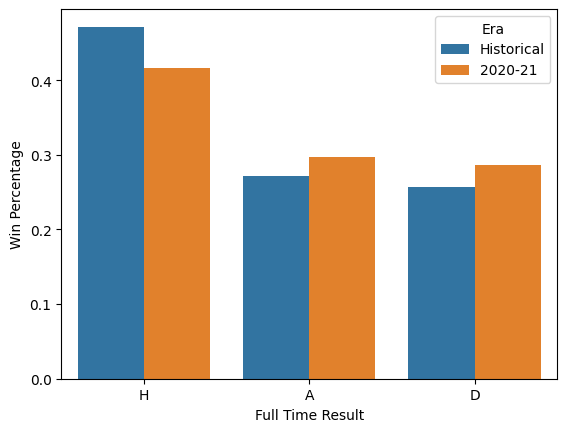

In [5]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.barplot(x = 'FTR', 
           y = 'WinRatePct', 
           hue = 'Era',
           data = merged_stats_pcts)


plt.xlabel('Full Time Result')
plt.ylabel('Win Percentage')
plt.show()


The data reveals a significant decrease in **Home Field Advantage** during the 2020-21 'Ghost Season'. We saw **Home win rates drop by approximately 5.6 percent points** compared to the 30-year baseline (from **47.2%** to **41.6%**). This declined was transfered by a nearly equal rise in both away wins and draws, suggesting that the absence of a home crown helped level the playing field.

### Goal Scoring Trends
Now we will look at the goal scoring trends throughout the years. More particularly, we are aiming to answer the following questions: 

* What is the average number of goals scored per match for each season?
* Is the league becoming more or less offensive over time?

#### Creating Total Goals Metric
This dataset has FTHG (Full-time home goals) and FTAG (Full-time away goals). We will create a new column in our DataFrame (`TotalGoals`) that represents the total number of goals scored in each specific match.

In [6]:
# Finding TotalGoals by adding both columns together
df['TotalGoals'] = df['FTAG'] + df['FTHG']

# Sanity Check
df.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,TotalGoals
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H,3
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H,3
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H,4
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D,5
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D,1


#### Aggregating goals by Season
Now that we have the total goals per match, we need to group our data by the Season column. Then we need to calculate the average (mean) of your new TotalGoals column for each season.

In [7]:
df.groupby('Season')['TotalGoals'].mean()

Season
1995-96      2.696970
1996-97      2.751082
1997-98      2.655263
1998-99      2.639474
1999-2000    2.628947
2000-01      2.881579
2001-02      2.528947
2002-03      2.673684
2003-04      2.671053
2004-05      2.578947
2005-06      2.463158
2006-07      2.478947
2007-08      2.686842
2008-09      2.897368
2009-10      2.713158
2010-11      2.742105
2011-12      2.763158
2012-13      2.871053
2013-14      2.750000
2014-15      2.655263
2015-16      2.744737
2016-17      2.942105
2017-18      2.694737
2018-19      2.586842
2019-20      2.478947
2020-21      2.507895
2021-22      2.502632
2022-23      2.513158
2023-24      2.644737
2024-25      2.618421
2025-26      2.610000
Name: TotalGoals, dtype: float64

#### Trend Analysis and Visualization
Now that we have our result, we can determine based on the data, is La Liga becoming more offensive, less offensive, or staying roughly the same over time by looking at the visualization. 

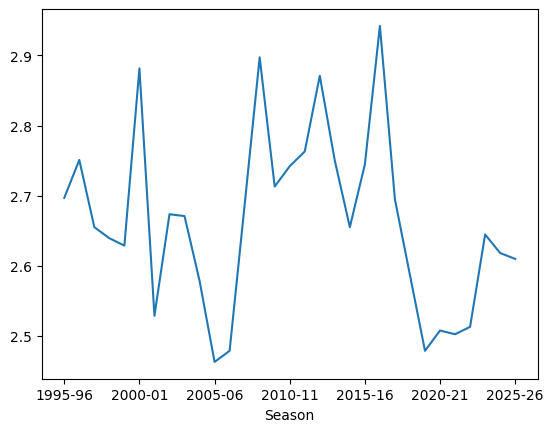

In [8]:
df.groupby('Season')['TotalGoals'].mean().plot()
plt.show()

There is not a clear, straight-line trend. The graph oscillates quite a bit, mostly bouncing between 2.5 and 2.9 goals per game. But if you look closely at that massive peak between 2008 and 2017, that perfectly aligns with the peak years of Lionel Messi at Barcelona and Cristiano Ronaldo at Real Madrid, where both teams were frequently scoring 100+ goals a season. The recent dip makes sense since by 2017 they have both left their perspective clubs. 

### Halftime Predictive Power
We now want to focus on if leading if a game is decided at haltime, and if there is even a chance of a comback happening. To solve this, we will answer the following: 

* How often does the team leading at halftime go on to win the match? 
* What is the 'comeback rate' for teams trailing at halftime?

To solve this, we need to compare the HTR (Half-time result) column with the FTR (Full-time result) column.

#### Isolating Halftime Leaders
We need to filter our data frame to only look at mathches where tehre was clear leader at halftime (meaning HTR is either 'H' for Home or 'A' for Away). We want to exclude games that were drawn ('D') at halftime for this specific calculation.

In [9]:
# Filtering out all the games where the teams were drawing againts each other at halftime
filtered_df = df[df['HTR'] != 'D']

# Sanity Check
filtered_df['HTR'].value_counts()

HTR
H    4104
A    2587
Name: count, dtype: int64

#### Calculating the "Hold the Lead" Rate
To calculate the "Hold the Lead" rate we are essentially asking ourselves: 

* Out of all the games where a team was leading at halftime, what percentage of them ended with that same team winning at full-time?

We start off by counting the number of games where the Half Time Result (HTR) is the same as the Full Time Result (FTR).

In [10]:
# This sums all the games in which the team who was leading at half time ended up winning 
hold_lead_count = (filtered_df['HTR'] == filtered_df['FTR']).sum()

# Getting the rate at which leading at half time leads to the team winning
hold_lead_rate = round((hold_lead_count / len(filtered_df)) * 100, 2)

print('Hold the Lead Rate: ')
print(str(hold_lead_rate) + '%')

Hold the Lead Rate: 
75.29%


The data reveals a significant correlation between halftime performance and final outcomes, with leading teams securing a victory in 75.29% of instances. This roughly 3-in-4 win probability suggests that a halftime lead in La Liga acts as a primary predictor of match success, leaving trailing opponents with a narrow statistical path to recovery.

#### Calculating the "Comeback" Rate
Similarly to how we calculated the "Hold the Lead" rate, we want to calculate how often to combacks happen. In order to answer this we are answering: 

* Out of all the games where a team was leading at halftime, what percentage of them ended with the trailing team pulling off a comeback win? (e.g., Home team leads at half, but Away team wins at full-time).

We start off by counting the number of games where the Half Time Result (HTR) is not the same Full Time Result (FTR) and the FTR is not a Draw.

In [11]:
# This sums all the games in which there was a comback and didn't end in a draw.
comeback_count = ((filtered_df['HTR'] != filtered_df['FTR']) & (filtered_df['FTR'] != 'D')).sum()

# Getting the rate at which this happens
comback_rate = round((comeback_count / len(filtered_df)) * 100, 2)

print('Comeback Rate: ')
print(str(comback_rate) + '%')

Comeback Rate: 
7.87%


A meager 7.87% comeback rate highlights the immense difficulty of altering a match's trajectory at the professional level. This suggests that leading teams in La Liga are highly proficient in "game management"—transitioning into a more rigid defensive structure and utilizing time-management tactics to neutralize threats and stifle the trailing team’s momentum.

### Comparative Analysis 
#### The Big Two vs. The Rest
Now instead of looking at the league as a whole, we are going to start slicing the data to compare specific groups. More specifically we are going to be focusing on the two biggest teams in La Liga (Real Madrid and Barcelona) againts everyone else. The very first question we will answer is the following: 

* Compare the average goal difference per match for Real Madrid and Barcelona against the rest of the league. 
* How has this gap evolved from the late 90s to today?

#### Creating Goal Difference Columns
In order to start to answer these questions we must: 

*	Get the Goal difference for every match
*	Create a Home_GD column (Home Goals minus Away Goals).
*	Create an Away_GD column (Away Goals minus Home Goals).

Note: A positive number means that team won by that many goals, a negative number means they lost by that many.

In [12]:
# Creating home goal difference column (FTHG - FTAG)
df['Home_GD'] = df['FTHG'] - df['FTAG']

# Creating away goal difference column (FTHG - FTAG)
df['Away_GD'] = df['FTAG'] - df['FTHG']

#### Isolating the Big Two
Now that we have the Goal Difference per match, we need to filter our dataframe so that it only contains matches for for Real Madrid and Barcelona. So that we can calculate the average Goal Difference.

In [13]:
# Filtering Real Madrid games and renaming the column to be able to merge the dataframes later
home_madrid = df[df['HomeTeam'] == 'Real Madrid'].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_madrid = df[df['AwayTeam'] == 'Real Madrid'].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

home_barca = df[df['HomeTeam'] == 'Barcelona'].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_barca = df[df['AwayTeam'] == 'Barcelona'].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

# Merging dataframes
merged_big_two = pd.concat([home_madrid, away_madrid, home_barca, away_barca])

# Getting the average goals scored
big_two_trend = merged_big_two.groupby('Season')['GD'].mean().reset_index()

#### Isolating "The Rest"
Now that we have gotten the average goals scored for Real Madrid and Barcelona as whole, we can move onto finding the average Goal Difference for all the other teams in the league to serve as our baseline comparison.

In [14]:
home_all = df[~df['HomeTeam'].isin(['Real Madrid', 'Barcelona'])].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_all = df[~df['AwayTeam'].isin(['Real Madrid', 'Barcelona'])].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

merged_all = pd.concat([home_all, away_all])

rest_trend = merged_all.groupby('Season')['GD'].mean().reset_index()

#### Visualizing the Gap
Now that we have both average goals difference grouped by season, we can see just how much better or worse Real Madrid, and Barcelona did compared to the rest of the league. 

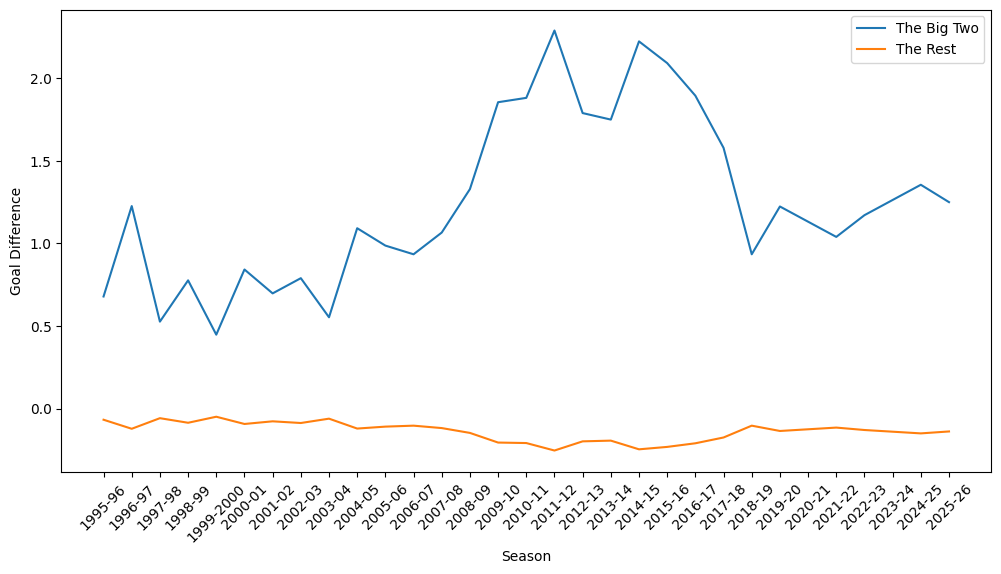

In [15]:
plt.figure(figsize=(12, 6))
sb.lineplot(data = big_two_trend, x = 'Season', y = 'GD', label = 'The Big Two')
sb.lineplot(data = rest_trend, x = 'Season', y = 'GD', label = 'The Rest')

plt.ylabel('Goal Difference')
plt.xticks(rotation = 45)
plt.legend()

plt.show()

The performance gap between the "Big Two" (Real Madrid and Barcelona) and the rest of La Liga reached its peak between 2008 and 2017. The average goal difference for the Big Two surged during this decade, peaking in the 2011–12 season at a level above 2.0. These stats perfectly captures the height of the Guardiola-Mourinho tactical rivalry and the individual peak of the Messi-Ronaldo era, where the league’s top two teams were levels above every other team in the league. 

#### Consistency Check
We will now focus on consistency. We want to figure out what team has stayed the most consistent throughout the years. We will answer the following: 

* Which team has the most consistent season-to-season performance in terms of total wins? 

#### The Win Stacking Strategy
We are going to use the same strategy we used when we calculated the Goal Difference of all the teams. the easiest way to figure this out is to create a "Master Team" DataFrame, but this time focusing on wins. We first need to: 

*	Create a column for Home_Win (e.g., True or 1 if FTR == 'H', else 0).
*	Create a column for Away_Win (e.g., True or 1 if FTR == 'A', else 0).
*	Create our stacked DataFrame

In [16]:
# Creating new columns based on condition
df['Home_Win'] = np.where(df['FTR'] == 'H', 1, 0)
df['Away_Win'] = np.where(df['FTR'] == 'A', 1, 0)

# Creating new dataframe, and renaming columns to be used for merging 
home_game_wins = df[['Season', 'HomeTeam', 'Home_Win']].rename(columns={'Home_Win': 'Num_Wins', 'HomeTeam': 'Team'})
away_game_wins = df[['Season', 'AwayTeam', 'Away_Win']].rename(columns={'Away_Win': 'Num_Wins', 'AwayTeam': 'Team'})

# Merging all dataframes
merged_game_wins = pd.concat([home_game_wins, away_game_wins]).groupby(['Season', 'Team'])['Num_Wins'].sum().reset_index()


# Sanity Check
print(home_game_wins.groupby(['Season', 'Team'])['Num_Wins'].sum().head())
print(away_game_wins.groupby(['Season', 'Team'])['Num_Wins'].sum().head())
print(merged_game_wins.head())


Season   Team      
1995-96  Albacete       7
         Ath Bilbao     9
         Ath Madrid    13
         Barcelona     15
         Betis          9
Name: Num_Wins, dtype: int64
Season   Team      
1995-96  Albacete       3
         Ath Bilbao     2
         Ath Madrid    13
         Barcelona      7
         Betis          7
Name: Num_Wins, dtype: int64
    Season        Team  Num_Wins
0  1995-96    Albacete        10
1  1995-96  Ath Bilbao        11
2  1995-96  Ath Madrid        26
3  1995-96   Barcelona        22
4  1995-96       Betis        16


### Calculating Standard Deviation 
Now that we have the total number of wins for each team we can calculate the **Standard Deviation** (A measurement of how spread out numbers are from the average (mean)). A lower standard deviation means the team’s win total barely changes from year to year. A higher standard deviation means they are highly erratic (e.g., winning the league one year, fighting relegation the next). 

In [17]:
counts = merged_game_wins['Team'].value_counts()
valid_values = counts[counts >= 10].index

filtered_merged_game_wins = merged_game_wins[merged_game_wins['Team'].isin(valid_values)].groupby('Team')['Num_Wins'].std()

print(filtered_merged_game_wins.sort_values())


Team
Zaragoza       2.489143
Santander      2.644964
Getafe         2.942302
Espanol        3.094569
Vallecano      3.239236
Levante        3.273268
Valladolid     3.289181
Ath Bilbao     3.444803
Osasuna        3.471592
Malaga         3.653161
Alaves         3.792223
Granada        3.917199
Villarreal     3.929377
Betis          3.983227
Celta          4.003332
Sociedad       4.064786
Mallorca       4.113119
Real Madrid    4.887773
Valencia       4.900296
Sevilla        4.965489
Barcelona      5.367765
La Coruna      5.370998
Ath Madrid     5.794511
Name: Num_Wins, dtype: float64


When analysing season-to-season performance consistency, something interesting happens: the most satistically "consistent" teams are always mid table teams, in other words satistical consistentency does correlate with dominance in the league. Teams like Real Madrid and Barcelona have higher volatiity this is because in title winnning seasons, they go on to winning 30+ games while they might a bad next season in which they only win 20, which causes their satistical consistentency to lower. 

In sports analytics, **statistical consistency does not equal dominance**. A low standard deviation should be interpreted as mediocrity, stagnation, and complacency. Whereas having a higher standard deviation equates to a teams hunger for success leading a team to push for a 30-win championship season creates massive statistical outliers compared to their "rebuilding" years.

#### Away Day Specialists
We are now moving on to our last comparative question, we want to focus on the team who has the best chance at winning away from home. We will be answering the following: 

* Which team has the highest ratio of away wins to home wins across the entire dataset?

We have part of the solution already. We will calculate the amount home wins and name it `Total_Home_Wins` and similaryly, we will calculate the total away wins and call it `Total_Away_Win` from there we can get the ratio of how deadly a team is on the road as they are at home

In [18]:
total_home_wins = home_game_wins.groupby('Team')['Num_Wins'].sum().reset_index().rename(columns = {'Num_Wins': 'Total_Home_Wins'})
total_away_wins = away_game_wins.groupby('Team')['Num_Wins'].sum().reset_index().rename(columns = {'Num_Wins': 'Total_Away_Wins'})

merged_total_wins = pd.merge(total_home_wins, total_away_wins, on='Team')
merged_total_wins['Away_Ratio'] = merged_total_wins['Total_Away_Wins'] / merged_total_wins['Total_Home_Wins']

print(merged_total_wins)

           Team  Total_Home_Wins  Total_Away_Wins  Away_Ratio
0        Alaves              111               59    0.531532
1      Albacete               20                9    0.450000
2       Almeria               51               25    0.490196
3    Ath Bilbao              285              149    0.522807
4    Ath Madrid              336              210    0.625000
5     Barcelona              437              316    0.723112
6         Betis              217              145    0.668203
7         Cadiz               24               19    0.791667
8         Celta              205              117    0.570732
9    Compostela               28               13    0.464286
10      Cordoba                1                2    2.000000
11        Eibar               50               27    0.540000
12        Elche               30               17    0.566667
13      Espanol              240              113    0.470833
14  Extremadura               17                3    0.176471
15      